# **Portfolio Descriptive Statistics**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import duckdb as dd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# from src.config import DATABASE_DIR, HOME_CREDIT_DB --- IGNORE ---
DATABASE_DIR = r"C:\Users\mario\OneDrive\Documents\Education\guide_repo\data\database"
HOME_CREDIT_DB = "home_credit_mds.db"

In [4]:
os.chdir(DATABASE_DIR)
con = dd.connect(HOME_CREDIT_DB)

## **Latest Key Metrics by Arrears Stage**

The table below shows an overview of the performing vs non-performing book as of the latest date (December 2012). There are approximately 48k performing accounts with total credit card balances of ฿5.8 billion.

In [5]:
query = """
    WITH latest_date AS (
        SELECT MAX(CALENDAR_DATE) AS MAX_DATE
        FROM credit_card_balance
    )
    SELECT 
        ARREARS_STAGE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        ROUND(SUM(AMT_BALANCE), 0) AS TOTAL_BALANCE,
        ROUND(AVG(AMT_CREDIT_LIMIT_ACTUAL), 0) AS AVG_CREDIT_LIMIT,
        ROUND(AVG(AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), 2) AS AVG_UTILISATION
    FROM credit_card_balance
    WHERE CALENDAR_DATE = (SELECT MAX_DATE FROM latest_date)
    GROUP BY ARREARS_STAGE
    ORDER BY ARREARS_STAGE;
"""
con.sql(query)

┌───────────────┬──────────────┬───────────────┬──────────────────┬─────────────────┐
│ ARREARS_STAGE │ TOTAL_VOLUME │ TOTAL_BALANCE │ AVG_CREDIT_LIMIT │ AVG_UTILISATION │
│    varchar    │    int64     │    double     │      double      │     double      │
├───────────────┼──────────────┼───────────────┼──────────────────┼─────────────────┤
│ 1. PERFORMING │        48607 │  5870190636.0 │         231332.0 │            0.43 │
│ 2. 1-30 DPD   │          270 │    46704991.0 │         180767.0 │            0.95 │
│ 3. 31-90 DPD  │            3 │      817385.0 │         262500.0 │            1.03 │
│ 4. 90+ DPD    │            7 │     1511875.0 │         176786.0 │            1.14 │
└───────────────┴──────────────┴───────────────┴──────────────────┴─────────────────┘

In [6]:
query = """
    SELECT MAX(CALENDAR_DATE) AS MAX_DATE
    FROM credit_card_balance;
"""
con.sql(query)

┌────────────┐
│  MAX_DATE  │
│    date    │
├────────────┤
│ 2012-12-01 │
└────────────┘

## **Historical Key Metrics by Arrears Stage**

The figures below show the historical volume, balance and credit limit by the different arrears stages. 


In [8]:
query = """
    SELECT 
        ARREARS_STAGE,
        CALENDAR_DATE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        ROUND(SUM(AMT_BALANCE), 0) AS TOTAL_BALANCE,
        ROUND(AVG(AMT_CREDIT_LIMIT_ACTUAL), 0) AS AVG_CREDIT_LIMIT,
        ROUND(AVG(AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), 2) AS AVG_UTILISATION,
        SUM("12M_DEFAULT_OUTCOME")/COUNT(DISTINCT SK_ID_PREV) AS "12M_DEFAULT_RATE"
    FROM credit_card_balance
    GROUP BY ARREARS_STAGE, CALENDAR_DATE
    ORDER BY ARREARS_STAGE, CALENDAR_DATE ASC;
"""
df = con.sql(query).df()

total_by_date = (
    df.groupby("CALENDAR_DATE")
    .agg(
        TOTAL_VOLUME=("TOTAL_VOLUME", "sum"),
        TOTAL_BALANCE=("TOTAL_BALANCE", "sum"),
    )
    .reset_index()
)

df_normalized = df.merge(total_by_date, on="CALENDAR_DATE", suffixes=("", "_TOTAL"))

for col in ["TOTAL_VOLUME", "TOTAL_BALANCE"]:
    df_normalized[col + "_NORM"] = (
        df_normalized[col] / df_normalized[col + "_TOTAL"] * 100
    )

### **Total Volume**

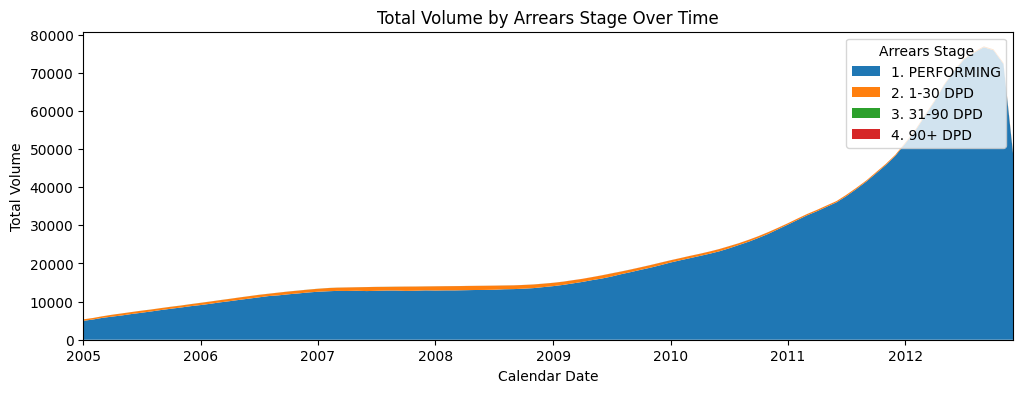

In [54]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_VOLUME"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Total Volume by Arrears Stage Over Time")
plt.ylabel("Total Volume")
plt.xlabel("Calendar Date")
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Volume %**

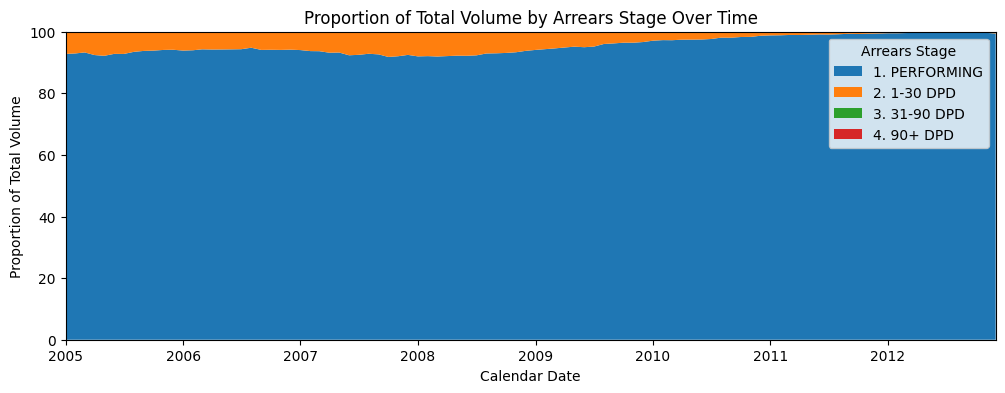

In [ ]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_VOLUME_NORM"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Proportion of Total Volume by Arrears Stage Over Time")
plt.ylabel("Proportion of Total Volume")
plt.xlabel("Calendar Date")
plt.ylim(0, 100)
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Balance**

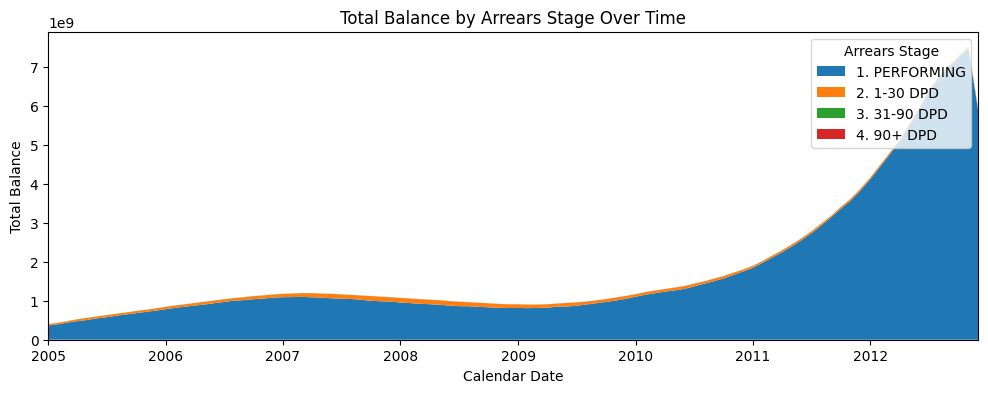

In [55]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_BALANCE"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Total Balance by Arrears Stage Over Time")
plt.ylabel("Total Balance")
plt.xlabel("Calendar Date")
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Balance %**

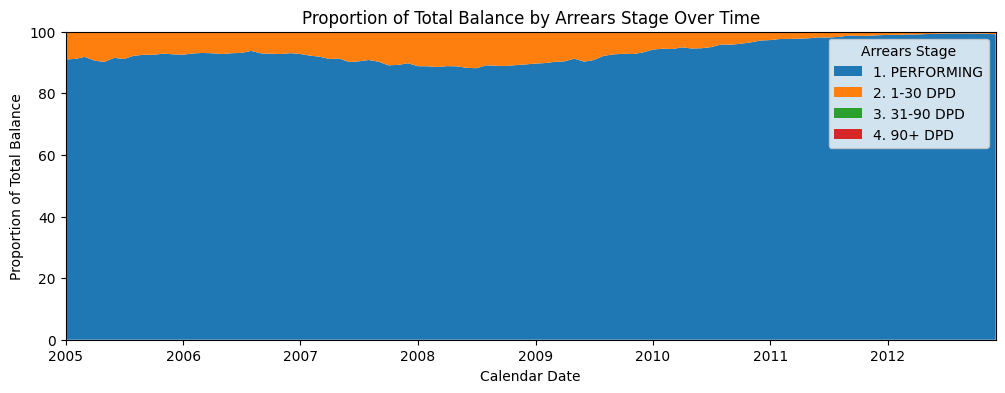

In [53]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_BALANCE_NORM"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Proportion of Total Balance by Arrears Stage Over Time")
plt.ylabel("Proportion of Total Balance")
plt.xlabel("Calendar Date")
plt.ylim(0, 100)
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Average Credit Limit**

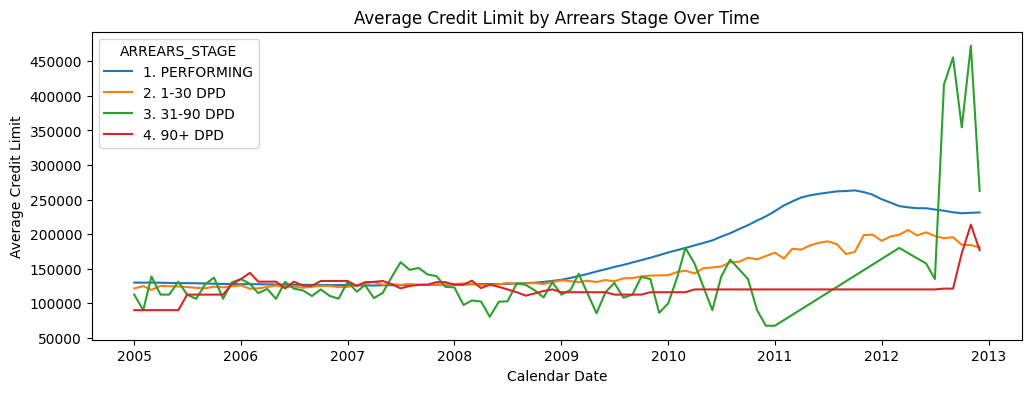

In [59]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="AVG_CREDIT_LIMIT", hue="ARREARS_STAGE"
)
plt.title("Average Credit Limit by Arrears Stage Over Time")
plt.ylabel("Average Credit Limit")
plt.xlabel("Calendar Date")
plt.show()

### **Average Utilisation**

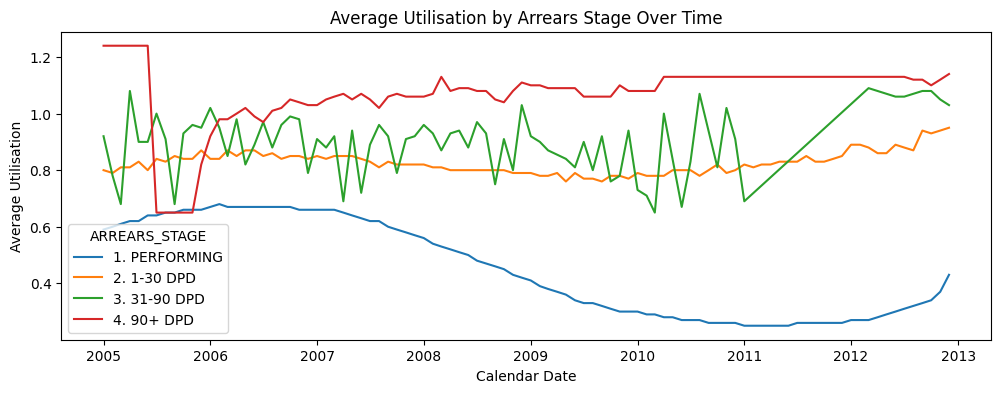

In [58]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="AVG_UTILISATION", hue="ARREARS_STAGE"
)
plt.title("Average Utilisation by Arrears Stage Over Time")
plt.ylabel("Average Utilisation")
plt.xlabel("Calendar Date")
plt.show()

### **Average 12M Default Rate**

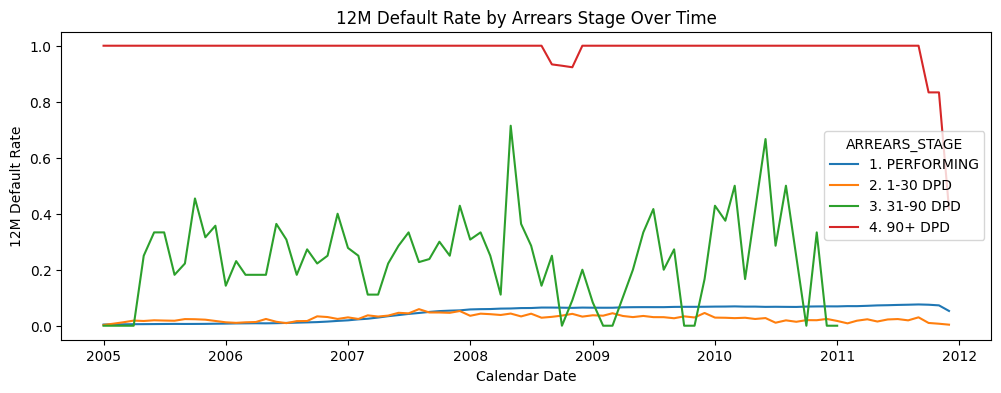

In [9]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="12M_DEFAULT_RATE", hue="ARREARS_STAGE"
)
plt.title("12M Default Rate by Arrears Stage Over Time")
plt.ylabel("12M Default Rate")
plt.xlabel("Calendar Date")
plt.show()